# Homework #4

## Regularization in Machine Learning

This colaboratory contains Homework #4 of the Machine Learning course, which is due **November 05, midnight (23:59 EEST time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.


## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:
1. Pooh

##List of Homework's exercises:

1.   [Ex1](#scrollTo=gCUvnKxZXTul) - 3 points
2.   [Ex2](#scrollTo=yLmunCZ9k-G6) - 4 points
3.   [Ex3](#scrollTo=lPdnuVSqeIN2) - 3 points
4.   [Bonus 1](#scrollTo=jdZkblZW7bEp) - up to 4 points (based on quality of presentation)


In [ ]:
!pip install -q plotnine
from plotnine import *

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

# loading in the cifar10 dataset
from keras.datasets import cifar10
from keras.layers import Input, Conv2D, Activation, Flatten, Dense, MaxPooling2D, BatchNormalization, Dropout
from keras import regularizers, optimizers, Sequential

In [ ]:
# Auxiliary functions
def plot_curves(history):
  plt.figure(figsize=(16, 6))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Training', 'Validation'])
  plt.title('Loss')

  plt.subplot(1, 2, 2)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Training', 'Validation'])
  plt.title('Accuracy')

## Homework exercise 1 (3 points): ElasticNet algorithm combines both Ridge and LASSO regression.
<font color='red'> In the class we discussed Ridge and Lasso regression algorithms, which are basically, L2 and L1 regularisations applied to Linear Regression model. ElasticNet is a method that combines both L2 and L1 regularisations under one model. ElasticNet adds both L2 and L1 norms to the error function. Here you should train and visualise ElasticNet model on the toy dataset. </font>


In [ ]:
# Let's regenerate training data one more time
example_data = pd.DataFrame({'x':[1,2,3,4,5], 'y':[2,4,5,4,5]})
example_data['x^2'] = example_data.x**2
example_data['x^3'] = example_data.x**3
example_data['x^4'] = example_data.x**4

visualisation_data = pd.DataFrame({'x': np.linspace(start=0, stop=6, num=61),
                          'x^2': np.linspace(start=0, stop=6, num=61)**2,
                          'x^3': np.linspace(start=0, stop=6, num=61)**3,
                          'x^4': np.linspace(start=0, stop=6, num=61)**4})

<font color='red'> **(Homework exercise 1- a)** Train ElasticNet as well as three other regression models (linear, ridge and lasso) using `sklearn` on example data. **(1 point)**. </font>

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

# Regularization strength
lambda_ = 1

##### YOUR CODE STARTS #####
# first initialise different regressions
# then fit them to our example_data
# finally predict the visualisation data
LR_model = LinearRegression()
Lasso_model = Lasso(alpha = lambda_)
Ridge_model = Ridge(alpha = lambda_)
Elastic_model = ElasticNet(alpha = lambda_)

LR_model.fit(example_data[['x', 'x^2', 'x^3', 'x^4']], example_data['y'])
Lasso_model.fit(example_data[['x', 'x^2', 'x^3', 'x^4']], example_data['y'])
Ridge_model.fit(example_data[['x', 'x^2', 'x^3', 'x^4']], example_data['y'])
Elastic_model.fit(example_data[['x', 'x^2', 'x^3', 'x^4']], example_data['y'])


visualisation_data['lr_y'] = LR_model.predict(visualisation_data[['x', 'x^2', 'x^3', 'x^4']])
visualisation_data['lasso_y'] = Lasso_model.predict(visualisation_data[['x', 'x^2', 'x^3', 'x^4']])
visualisation_data['ridge_y'] = Ridge_model.predict(visualisation_data[['x', 'x^2', 'x^3', 'x^4']])
visualisation_data['elastic_y'] = Elastic_model.predict(visualisation_data[['x', 'x^2', 'x^3', 'x^4']])
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 1- b)** Visualise all four regression trends (baseline, LASSO, Ridge and ElasticNet) on the same figure. Highlight ElasticNet in <font color='#F1C40F'>yellow</font>, while others in black (linear), red (ridge) and blue (lasso). **(1 point)**. </font>


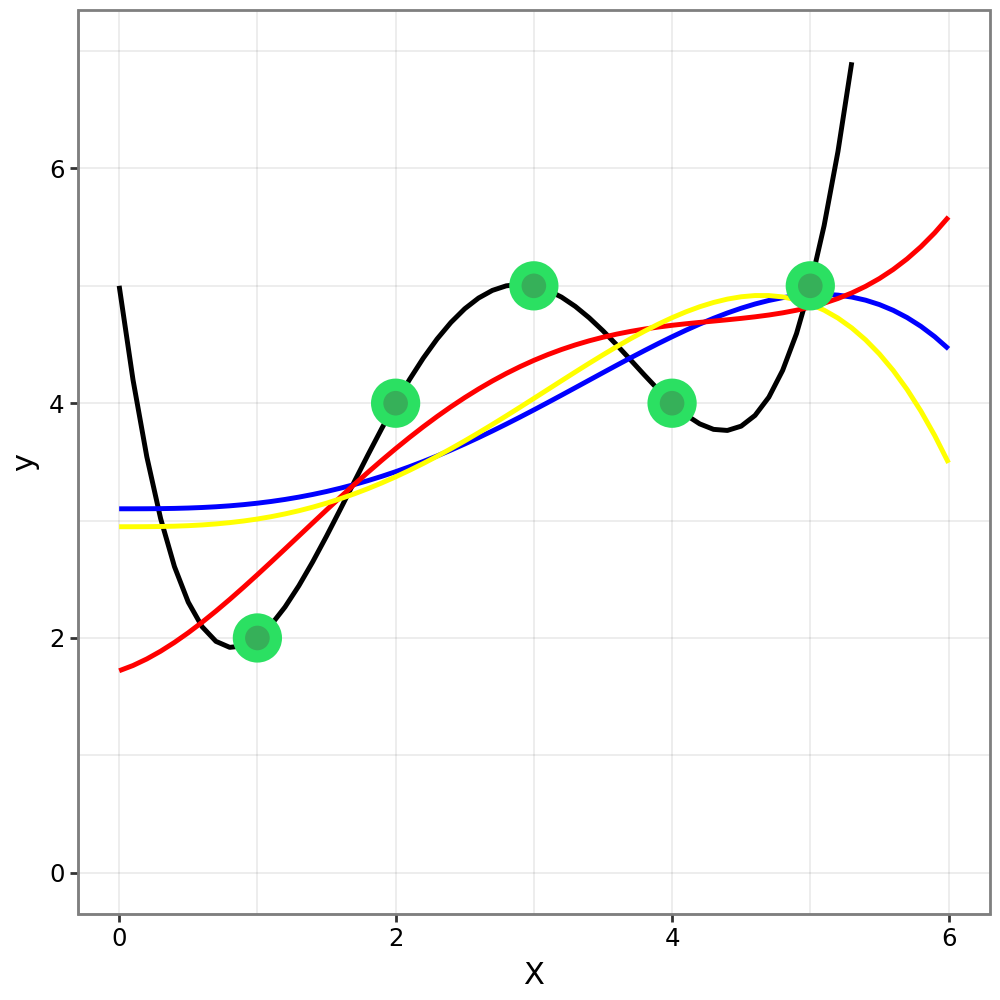

In [ ]:
fig = (
    ggplot(data = example_data,
          mapping = aes(x = 'x', y = 'y')) +
       ##### YOUR CODE STARTS #####
       geom_path(visualisation_data, aes(x = 'x', y = 'lr_y'),  color = 'black', size = 1) +
       geom_path(visualisation_data, aes(x = 'x', y = 'lasso_y'),  color = 'blue', size = 1) +
       geom_path(visualisation_data, aes(x = 'x', y = 'ridge_y'),  color = 'red', size = 1) +
       geom_path(visualisation_data, aes(x = 'x', y = 'elastic_y'),  color = 'yellow', size = 1) +
       ##### YOUR CODE ENDS #####
    geom_point(fill = '#36B059',
               size = 5.0,
               stroke = 2.5,
               colour = '#2BE062',
               shape = 'o') +
    labs(
        title ='',
        x = 'X',
        y = 'y',
    ) +
    xlim(0, 6) +
    ylim(0, 7) +
    theme_bw() +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black')) +
    guides(size = False)
)
fig


<font color='red'> **(Homework exercise 1- c)** Print out ElasticNet coefficients and intercept, compare it to coefficients and intercept of other regressions. Which one ElasticNet seems to be more similar to? Which parameter in `sklearn.ElasticNet` function is responsible for mixing of L1 and L2 regularisation? **(1 point)**. </font>

In [ ]:
##### YOUR CODE STARTS #####
print(f'ElasticNet regression coefficients are: [{Elastic_model.coef_}], intercept = {Elastic_model.intercept_:.2f}')
print(f'LR regression coefficients are: [{LR_model.coef_}], intercept = {LR_model.intercept_:.2f}')
print(f'Ridge regression coefficients are: [{Ridge_model.coef_}], intercept = {Ridge_model.intercept_:.2f}')
print(f'Lasso regression coefficients are: [{Lasso_model.coef_}], intercept = {Lasso_model.intercept_:.2f}')
##### YOUR CODE ENDS #####

ElasticNet regression coefficients are: [[ 0.          0.          0.07844547 -0.01265445]], intercept = 2.95
LR regression coefficients are: [[-8.75        7.79166667 -2.25        0.20833333]], intercept = 5.00
Ridge regression coefficients are: [[ 0.3882215   0.61877466 -0.20687874  0.0184773 ]], intercept = 1.72
Lasso regression coefficients are: [[ 0.          0.          0.05608653 -0.00829621]], intercept = 3.10


<font color='red'> Your textual answer goes here: </font> We can see that the biggest intercept has Linear Regression because it does not use any regularisation. Also, we can tell that in this situation Lasso_model decided that the first two features are not useful. It is an amazing example of feature selection with the help of L1. ElasticNet looks similar to Lasso regression; we can see that in ElasticNet we also have the first two features equal to 0. For mixing in ElasticNet responsible parametr l1_ratio
(l1_ratio : float, default=0.5 The ElasticNet mixing parameter)

## Homework exercise 2 (4 points): searching for good dropout rate and lambda
<font color='red'>  </font>

In [ ]:
# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

# Normalising values
mu = X_train.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train.std(axis=(0,1,2)) # same for std
X_train_norm = (X_train - mu)/std
X_test_norm = (X_test - mu)/std

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


<font color='red'>**(Homework exercise 2-a)**
Create a new function `define_model_dropout_lambda`, which takes both dropout and lambda as input parameters. **(0.5 points)**</font>


In [ ]:
def define_model_dropout_lambda(dropout_rate, lambda_):
  model = Sequential()
  ##### YOUR CODE STARTS #####

  model = Sequential()

  model.add(Conv2D(16, (3,3), padding='same', input_shape=(32, 32, 3), kernel_regularizer = regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Flatten())
  model.add(Dense(10, activation='softmax'))
  ##### YOUR CODE ENDS #####
  return model

<font color='red'> **(Homework exercise 2- b)** Run K-Fold cross-validation using sklearn. Fill in the gaps to collect validation accuracy scores for each dropout rate and lambda. **(2 points)**. </font>


In [ ]:
from sklearn.model_selection import KFold
import gc
from keras import backend as K
from tensorflow.keras.backend import clear_session

dropout_rates = [0.0, 0.1, 0.25, 0.5, 0.99]  # feel free to choose other values to loop over
lambdas = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]  # feel free to choose other values to loop over

# you can collect both accuracy and loss if you like,
# but loss is influenced by the regularisation itself, so maybe less informative
val_fold_acc = np.zeros((len(dropout_rates), len(lambdas)))
val_fold_loss = np.zeros((len(dropout_rates), len(lambdas)))

for i, dropout_rate in enumerate(dropout_rates):
  for j, lambda_ in enumerate(lambdas):
    ##### YOUR CODE STARTS #####
    # 4-fold cross validation
    # Here we are using sklearn Cross Validation Function called KFold
    kf = KFold(n_splits=4, shuffle=True, random_state=111)

    # Do not change these lines, we initialize empty lists
    fold_acc = []
    fold_loss = []
    for train_index, val_index in kf.split(X_train_norm):

      # split data into train_X, train_y and val_X, val_y depending on the fold:
      train_X = X_train_norm[train_index]
      train_y = y_train[train_index]

      val_X = X_train_norm[val_index]
      val_y = y_train[val_index]

      clear_session()

      # create a neural network with chosen dropout_rate and lambda
      model = define_model_dropout_lambda(dropout_rate, lambda_)

      # compile the model
      model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizers.AdamW(learning_rate=0.001), metrics=['accuracy'])

      # fit the neural network on training data
      # number of epochs is tricky, if you choose too little the performance will be unstable
      # if you choose too large, it will take ages to complete...
      # we will remove the output with verbose=0 to avoid long printouts
      model.fit(train_X, train_y, epochs = 2, verbose=0)

      # calculate accuracy for this fold and store it in fold_acc

      res = model.evaluate(val_X, val_y)
      fold_acc.append(res[1])

      # and loss in fold_loss
      fold_loss.append(res[0])

      # Clear memory
      del model
      K.clear_session()
      gc.collect()

    ##### YOUR CODE ENDS #####

    print(f'Average validation accuracy for dropout {dropout_rate} and lambda {lambda_} is {np.mean(fold_acc)}')
    val_fold_acc[i][j] = np.mean(fold_acc)
    val_fold_loss[i][j] = np.mean(fold_loss)

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5040 - loss: 1.5306
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4878 - loss: 1.5501
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5018 - loss: 1.5043
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5082 - loss: 1.5034
Average validation accuracy for dropout 0.0 and lambda 0.1 is 0.5004400014877319
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5155 - loss: 1.4581
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5202 - loss: 1.3998
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5210 - loss: 1.4136
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5117 - loss: 1.4264
Average validation accuracy for dropout 0.0 and lambda 0.01 is 0.5170799940824509
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5146 - loss: 1.4013
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4843 - loss: 1.4586
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4949 - loss: 1.4342
196/196 ━━

<font color='red'> **(Homework exercise 2- c)** Create a heatmap plot that shows validation accuracy or loss (choose for yourself) for different dropout rates and lambdas that you have tried, report the best one. You can check [the docs](https://seaborn.pydata.org/generated/seaborn.heatmap.html) on how to create heatmaps. **(0.5 points)**. </font>


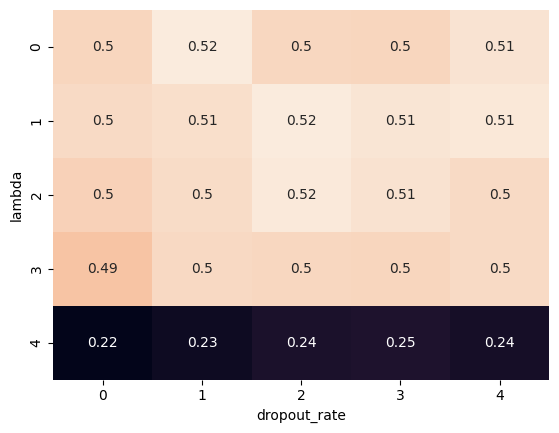

In [ ]:
##### YOUR CODE STARTS #####
sns.heatmap(val_fold_acc, annot=True, cbar=False)
plt.xlabel('dropout_rate')
plt.ylabel('lambda')
plt.show()
##### YOUR CODE ENDS #####

According to the above graphs, the best dropout rate and lambda seem to be dropout 0.1 and lambda 0.001

<font color='red'> **(Homework exercise 2- d)** Re-train the model using the dropout rate and lambda reported in **(c)**. Visualise performance curves and interpret the results. If results did not improve, no need to re-run the process again, just comment on the results. **(1 point)**. </font>

In [ ]:
##### YOUR CODE STARTS #####
# Define the model with identified dropout rate and lambda and compile it
model = Sequential()

model.add(Conv2D(16, (3,3), padding='same', input_shape=(32, 32, 3), kernel_regularizer = regularizers.l2(0.1)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.65))

model.add(Flatten())
model.add(Dense(10, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.AdamW(learning_rate=0.001), metrics=['accuracy'])
# Fit the model; return history object

history = model.fit(X_test_norm, y_test, epochs = 30, batch_size = 100, validation_split=0.2)

print(history)
##### YOUR CODE ENDS #####

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.2789 - loss: 2.4460 - val_accuracy: 0.3815 - val_loss: 2.0583
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.3997 - loss: 1.9628 - val_accuracy: 0.4255 - val_loss: 1.8332
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.4395 - loss: 1.7709 - val_accuracy: 0.4600 - val_loss: 1.7098
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.4659 - loss: 1.6478 - val_accuracy: 0.4620 - val_loss: 1.6491
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.4920 - loss: 1.5651 - val_accuracy: 0.4840 - val_loss: 1.5796
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5038 - loss: 1.5093 - val_accuracy: 0.4795 - val_loss: 1.5351
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.5195 - loss: 1.4613 - val_accuracy: 0.4950 - val_loss: 1.5094
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.5275 - loss: 1.4310 - val_accuracy: 0.5040 - v

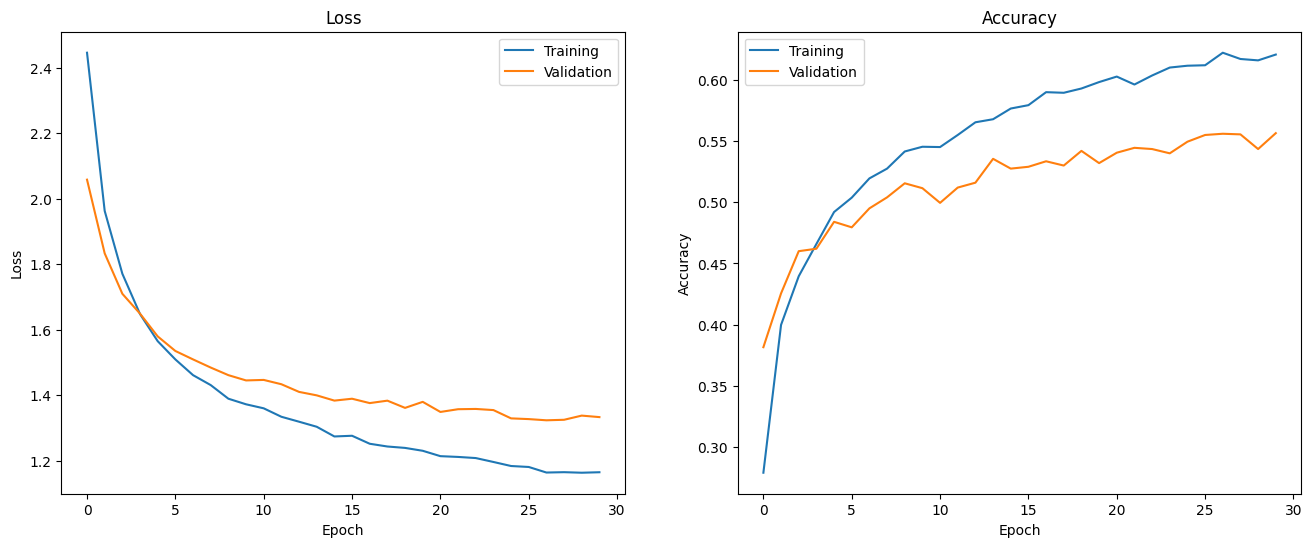

In [ ]:
##### YOUR CODE STARTS #####
# plot the progress curves here
plot_curves(history)
##### YOUR CODE ENDS #####

In [ ]:
##### YOUR CODE STARTS #####
# evaluate the model here
model.evaluate(X_test_norm, y_test)
##### YOUR CODE ENDS #####

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7863 - loss: 0.7037


[0.7037025690078735, 0.786300003528595]

<font color='red'> Your insightful interpretation of the results goes here: </font> Here I understood that in part when we with CV tried to find the best combination of dropout and L2 rate I had small amount of epoch

...

## Homework exercise 3 (3 points): applying more sophisticated augmentation pipelines
<font color='red'> Check https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator and add more interesting transformation into the pipeline we have developed in the class. Train your network again, and interpret the results. First of all some setup. </font>

In [ ]:
# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step



<font color='red'> **(Homework exercise 3- a)** Add at least 2-3 more different transformations described at https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator. Augment CIFAR10 training images. Visualise a few random augmentated images (as we have done for the simple augmentation pipeline in the class). This time, make 5 by 5 grid instead of 3 by 3. **(1 point)**. </font>


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

##### YOUR CODE STARTS #####
# Create your own data augmentation pipeline:

datagen = ImageDataGenerator(zoom_range=0.1, vertical_flip=True)

datagen.fit(X_train)
##### YOUR CODE ENDS #####

ValueError: num must be an integer with 1 <= num <= 9, not 10

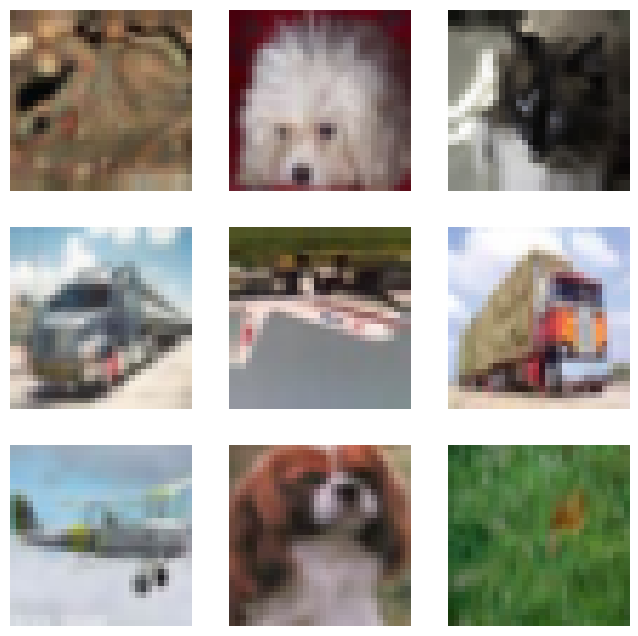

In [ ]:
##### YOUR CODE STARTS #####
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots

# Configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9):
    # Show 25 images
    for i in range(0, 25):
        plt.subplot(3, 3, 1 + i)
        plt.imshow(X_batch[i].astype('uint8'))
        plt.axis('off')
    # show the plot
    plt.show()
    break
##### YOUR CODE ENDS #####

<font color='red'> Here, briefly explain your choice of augmentation pipeline (i.e. why these augmentation you added will help?) </font>

<font color='red'> Your textual answer goes here: </font> First of all it will help because its data augmentation. Zoom i think help beacuse it maybe help receive main feature in the middle of picture and in higher resolution. Vertical flip can help because, for example, an animal can appear in different positions in an image

<font color='red'> **(Homework exercise 3- b)** First, split the training data into train and validation sets using `train_test_split` function from `sklearn` (use 10% for validation). Then normalise each of the three sets (train, val and test) using mean and standard deviations computed on train images (for R, G and B separately). Finally, retrain the model using this new augmented training set. Use non-augmented normalised validation set for validation of the model while training. **(1.5 points)**. </font>

In [ ]:
from sklearn.model_selection import train_test_split

##### YOUR CODE STARTS #####
# Split the training data further into train and val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1)

mu = X_train.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train.std(axis=(0,1,2))# same for std
X_train_norm = (X_train - mu)/std
X_val_norm = (X_val - mu)/std
X_test_norm = (X_test - mu)/std
##### YOUR CODE ENDS #####

# Assign augmentation schema to X_train_norm
datagen.fit(X_train_norm)

In [ ]:
##### YOUR CODE STARTS #####
# Create a model
# here you can use either model with dropout or/and L2 regularisation defined above
model = Sequential()

model.add(Conv2D(16, (3,3), padding='same', input_shape=(32, 32, 3), kernel_regularizer = regularizers.l2(0.1)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.65))

model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# Compile the model as before (code is identical)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.AdamW(learning_rate=0.001), metrics=['accuracy'])

# remember to use .fit() to train the model
# use batch_size 64 as in the class
history = model.fit(datagen.flow(X_train_norm, y_train, batch_size=64), epochs=30)
##### YOUR CODE ENDS #####

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.3056 - loss: 2.1723
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.3882 - loss: 1.7824
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.4136 - loss: 1.6889
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4288 - loss: 1.6478
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.4397 - loss: 1.6133
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4490 - loss: 1.5864
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4507 - loss: 1.5731
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4494 - loss: 1.5696
Epoch 9/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.4599 - loss: 1.5573
Epoch 10/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4595 - loss: 1.5424
Epoch 11/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.4607 - loss: 1.5396
Epoch 12/30
352/352 ━━━━━━━━━━


<font color='red'> **(Homework exercise 3- c)** Plot the performance curves (loss and accuracy), evaluate your model on the non-augmented normalised test set and interpret the results. Did the performance improve? Why? Why not? **(0.5 points)**. </font>

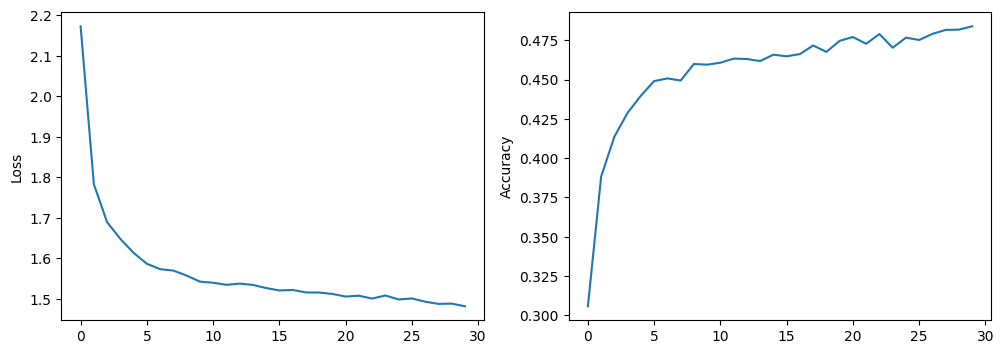

In [ ]:
##### YOUR CODE STARTS #####
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.ylabel('Accuracy')

plt.show()
##### YOUR CODE ENDS #####

In [ ]:
##### YOUR CODE STARTS #####
model.evaluate(X_test_norm, y_test)
##### YOUR CODE ENDS #####

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5071 - loss: 1.4336


[1.4335994720458984, 0.507099986076355]

<font color='red'> Textual answer to (**c**) goes here: </font> I received accuracy twenty percent less.



...

# Bonus exercises
*(NB, these are optional exercises!)*


## Implement CutMix from scratch (up to 4 bonus points depending on presentation):
<font color='red'> Experimentally verify if CutMix augmentation helps to improve the test score on CIFAR10 (not clear, as images are very tiny). Link to the CutMix paper: https://arxiv.org/abs/1905.04899. Implement and show couple of examples images augmented with CutMix. Test its performance and visualise the corresponding accuracy and loss curves. Compare the results of model trained on CutMix augmented images to the model trained without data augmentation. </font>


10 25 20 35
12


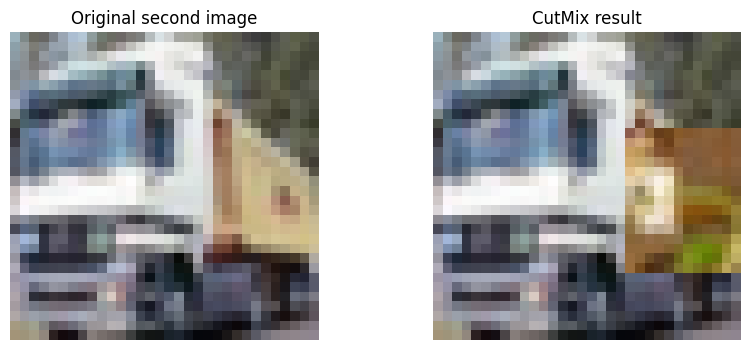

In [ ]:
##### YOUR CODE STARTS #####
def cutmix_one(data, labels):
  first_img = data[0]
  second_img = data[1]

  percent_changes = np.random.uniform(0, 0.5)

  rozmir = first_img.shape[1]

  first_pixel_x = np.random.randint(0, rozmir)

  if first_pixel_x * percent_changes > rozmir:
    last_pixel_x = rozmir
  else:
      last_pixel_x = round(first_pixel_x + rozmir * percent_changes)


  first_pixel_y = np.random.randint(0, rozmir)

  if first_pixel_y * percent_changes > rozmir:
    last_pixel_y = rozmir
  else:
      last_pixel_y = round(first_pixel_y + rozmir * percent_changes)


  print(first_pixel_x, last_pixel_x, first_pixel_y, last_pixel_y)


  vurizane = first_img[first_pixel_x:last_pixel_x, first_pixel_y:last_pixel_y]


  print(vurizane.shape[1])


  second_img[first_pixel_x:last_pixel_x, first_pixel_y:last_pixel_y] = vurizane



  labels[1] = [percent_changes, 1 - percent_changes]


  return data, labels

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

orig = X_train[1].copy()

orig_label = y_train[1].copy()

x, y = cutmix_one([X_train[0], X_train[1]], [y_train[0], y_train[1]])

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original second image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(x[1])
plt.title("CutMix result")
plt.axis("off")

plt.show()




##### YOUR CODE ENDS #####

In [ ]:
#Comparison part
##### YOUR CODE STARTS #####

##### YOUR CODE ENDS #####

<font color='red'> Your explanation: </font>

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you send on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

# <font color='red'>  End of the homework. Please don't delete this cell.</font>